# Predicting Employee Attrition Using Remote Work Productivity and Workplace Factors

**Team Members:** Gurpreet Kaur, Badamgarav Battushig  
**Course:** CPSC 5071 – Data Management for Data Science  
**Instructor:** Yueting Chen

### Import All Necessary Libraries

In [67]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import the Dataset

In [65]:
# Load datasets
url1 = "https://raw.githubusercontent.com/Kaurgurpreet23/CPSC5071/refs/heads/main/data/HR_Analytics.csv"
url2 = "https://raw.githubusercontent.com/Kaurgurpreet23/CPSC5071/refs/heads/main/data/remote_worker_productivity_1000.csv"
attrition = pd.read_csv(url1)
productivity = pd.read_csv(url2)

# Create SQLite DB
conn = sqlite3.connect("employee_project.db")

# Store tables
attrition.to_sql("attrition", conn, if_exists="replace", index=False)
productivity.to_sql("productivity", conn, if_exists="replace", index=False)

print("Tables created")

Tables created


### Examine Data

##### View Rows

In [2]:
pd.read_sql("SELECT * FROM attrition LIMIT 5", conn)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


##### Count Records

In [3]:
pd.read_sql("SELECT COUNT(*) FROM attrition", conn)

,COUNT(*)
0,1470


##### Check Missing Values

In [4]:
# Check missing values per column
print("Missing values in attrition dataset:")
print(attrition.isna().sum())

print("\nMissing values in productivity dataset:")
print(productivity.isna().sum())

# Optional: total missing values in entire dataset
print("\nTotal missing values in attrition dataset:", attrition.isna().sum().sum())
print("Total missing values in productivity dataset:", productivity.isna().sum().sum())

Missing values in attrition dataset:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Yea

### Aggregate Datasets

##### Aggregate productivity metrics by employee

In [5]:
agg_prod = pd.read_sql("""
SELECT
    worker_id,
    AVG(productivity_score) AS avg_productivity,
    AVG(average_daily_work_hours) AS avg_daily_hours,
    AVG(task_completion_rate) AS avg_task_completion,
    AVG(late_task_ratio) AS avg_late_ratio,
    AVG(focus_time_minutes) AS avg_focus_minutes
FROM productivity
GROUP BY worker_id
""", conn)

# Store aggregated productivity metrics
agg_prod.to_sql("prod_agg", conn, if_exists="replace", index=False)

1000

##### Join aggregated productivity with attrition

In [6]:
# If attrition EmployeeNumber matches worker_id in productivity
attrition_with_prod = pd.read_sql("""
SELECT a.*, p.avg_productivity, p.avg_daily_hours,
       p.avg_task_completion, p.avg_late_ratio, p.avg_focus_minutes
FROM attrition a
LEFT JOIN prod_agg p
ON a.EmployeeNumber = p.worker_id
""", conn)

##### Check for missing values after join

In [7]:
attrition_with_prod.isna().sum()

Age                            0
Attrition                      0
BusinessTravel                 0
DailyRate                      0
Department                     0
DistanceFromHome               0
Education                      0
EducationField                 0
EmployeeCount                  0
EmployeeNumber                 0
EnvironmentSatisfaction        0
Gender                         0
HourlyRate                     0
JobInvolvement                 0
JobLevel                       0
JobRole                        0
JobSatisfaction                0
MaritalStatus                  0
MonthlyIncome                  0
MonthlyRate                    0
NumCompaniesWorked             0
Over18                         0
OverTime                       0
PercentSalaryHike              0
PerformanceRating              0
RelationshipSatisfaction       0
StandardHours                  0
StockOptionLevel               0
TotalWorkingYears              0
TrainingTimesLastYear          0
WorkLifeBa

##### Check data types

In [8]:
print(attrition['EmployeeNumber'].head())
print(productivity['worker_id'].head())

0    1
1    2
2    4
3    5
4    7
Name: EmployeeNumber, dtype: int64
0    W0001
1    W0002
2    W0003
3    W0004
4    W0005
Name: worker_id, dtype: object


##### Fix mismatched types

In [9]:
attrition['EmployeeNumber'] = attrition['EmployeeNumber'].astype(str)
productivity['worker_id'] = productivity['worker_id'].astype(str)

##### Aggregate Datasets again

In [10]:
agg_prod = productivity.groupby('worker_id').agg(
    avg_productivity=('productivity_score', 'mean'),
    avg_daily_hours=('average_daily_work_hours', 'mean'),
    avg_task_completion=('task_completion_rate', 'mean'),
    avg_late_ratio=('late_task_ratio', 'mean'),
    avg_focus_minutes=('focus_time_minutes', 'mean')
).reset_index()

# Merge in pandas
attrition_with_prod = attrition.merge(agg_prod, left_on='EmployeeNumber', right_on='worker_id', how='left')

In [11]:
attrition_with_prod.isna().sum()

Age                            0
Attrition                      0
BusinessTravel                 0
DailyRate                      0
Department                     0
DistanceFromHome               0
Education                      0
EducationField                 0
EmployeeCount                  0
EmployeeNumber                 0
EnvironmentSatisfaction        0
Gender                         0
HourlyRate                     0
JobInvolvement                 0
JobLevel                       0
JobRole                        0
JobSatisfaction                0
MaritalStatus                  0
MonthlyIncome                  0
MonthlyRate                    0
NumCompaniesWorked             0
Over18                         0
OverTime                       0
PercentSalaryHike              0
PerformanceRating              0
RelationshipSatisfaction       0
StandardHours                  0
StockOptionLevel               0
TotalWorkingYears              0
TrainingTimesLastYear          0
WorkLifeBa

The missing values are still the same so we cannot perform a direct join on employee IDs because the two datasets represent different populations and do not share matching identifiers. Instead, it is necessary to aggregate the productivity data based on meaningful features that allow for a valid comparison. For example, we can calculate the average productivity for each experience level  or the average productivity. Once the productivity metrics are aggregated by these features, we will join the datasets using the aggregated feature rather than attempting to match individual employee IDs.


In [12]:
# Aggregate productivity by experience_years
agg_prod_exp = productivity.groupby('experience_years').agg(
    avg_productivity=('productivity_score', 'mean'),
    avg_daily_hours=('average_daily_work_hours', 'mean'),
    avg_task_completion=('task_completion_rate', 'mean'),
    avg_late_ratio=('late_task_ratio', 'mean'),
    avg_focus_minutes=('focus_time_minutes', 'mean')
).reset_index()

Now lets map each employee to their experience level (TotalWorkingYears) and join on that instead of employee ID.

In [13]:
# Example: map attrition TotalWorkingYears to nearest experience_years
attrition_with_prod = attrition.merge(
    agg_prod_exp,
    left_on='TotalWorkingYears',  # or a binned version
    right_on='experience_years',
    how='left'
)

In [14]:
attrition_with_prod.isna().sum()

Age                          0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears            0
TrainingTimesLastYear        0
WorkLifeBalance              0
YearsAtCompany               0
YearsInC

### Handling missing values by average

In [16]:
attrition_with_prod.fillna({
    'avg_productivity': attrition_with_prod['avg_productivity'].mean(),
    'avg_daily_hours': attrition_with_prod['avg_daily_hours'].mean(),
    'avg_task_completion': attrition_with_prod['avg_task_completion'].mean(),
    'avg_late_ratio': attrition_with_prod['avg_late_ratio'].mean(),
    'avg_focus_minutes': attrition_with_prod['avg_focus_minutes'].mean(),
    'experience_years': attrition_with_prod['experience_years'].mean()
}, inplace=True)

In [17]:
attrition_with_prod.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [18]:
# Total missing values in the dataset
total_missing = attrition_with_prod.isna().sum().sum()
print("Total missing values in dataset:", total_missing)

Total missing values in dataset: 0


### Merge using SQL

In [19]:
agg_prod_exp_sql = """
-- Aggregate productivity metrics per experience level
SELECT
    experience_years,
    AVG(productivity_score) AS avg_productivity,
    AVG(average_daily_work_hours) AS avg_daily_hours,
    AVG(task_completion_rate) AS avg_task_completion,
    AVG(late_task_ratio) AS avg_late_ratio,
    AVG(focus_time_minutes) AS avg_focus_minutes
FROM productivity
GROUP BY experience_years
"""
agg_prod_exp = pd.read_sql(agg_prod_exp_sql, conn)

# Save the aggregated table in SQLite
agg_prod_exp.to_sql("prod_agg_exp", conn, if_exists="replace", index=False)

34

In [21]:
merged_sql = """
-- Join attrition with aggregated productivity on experience
SELECT
    a.*,
    p.avg_productivity,
    p.avg_daily_hours,
    p.avg_task_completion,
    p.avg_late_ratio,
    p.avg_focus_minutes
FROM attrition a
LEFT JOIN prod_agg_exp p
ON a.TotalWorkingYears = p.experience_years
"""
attrition_with_prod_sql = pd.read_sql(merged_sql, conn)

In [22]:
merged_sql_fillna = """
SELECT
    a.*,
    COALESCE(p.avg_productivity, (SELECT AVG(productivity_score) FROM productivity)) AS avg_productivity,
    COALESCE(p.avg_daily_hours, (SELECT AVG(average_daily_work_hours) FROM productivity)) AS avg_daily_hours,
    COALESCE(p.avg_task_completion, (SELECT AVG(task_completion_rate) FROM productivity)) AS avg_task_completion,
    COALESCE(p.avg_late_ratio, (SELECT AVG(late_task_ratio) FROM productivity)) AS avg_late_ratio,
    COALESCE(p.avg_focus_minutes, (SELECT AVG(focus_time_minutes) FROM productivity)) AS avg_focus_minutes
FROM attrition a
LEFT JOIN prod_agg_exp p
ON a.TotalWorkingYears = p.experience_years
"""
attrition_with_prod_sql = pd.read_sql(merged_sql_fillna, conn)

In [23]:
# Total number of missing values across the whole dataset
total_missing = attrition_with_prod_sql.isna().sum().sum()
print("Total missing values in dataset:", total_missing)

Total missing values in dataset: 0


### Data Processing

##### Data Cleaning

In [ ]:
# Remove duplicates
df = attrition_with_prod_sql.drop_duplicates()

# Correct data types for categorical columns
categorical_cols = ['Attrition', 'BusinessTravel', 'Department', 'EducationField',
                    'Gender', 'Over18', 'OverTime', 'JobRole', 'MaritalStatus']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Cap outliers in numeric columns (example: MonthlyIncome)
Q1 = df['MonthlyIncome'].quantile(0.01)
Q99 = df['MonthlyIncome'].quantile(0.99)
df['MonthlyIncome'] = np.clip(df['MonthlyIncome'], Q1, Q99)

### Data Integration

In [25]:
# Already merged HR attrition dataset with productivity metrics by experience levels
# Productivity metrics: avg_productivity, avg_daily_hours, avg_task_completion, avg_late_ratio, avg_focus_minutes
print("Dataset shape after integration:", df.shape)

Dataset shape after integration: (1470, 40)


### Data Normalization

In [26]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode target variable 'Attrition'
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])  # Yes=1, No=0

# Scale numeric features
num_cols = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
            'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
            'YearsSinceLastPromotion', 'YearsWithCurrManager',
            'avg_productivity', 'avg_daily_hours', 'avg_task_completion',
            'avg_late_ratio', 'avg_focus_minutes']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

### EDA Analysis

##### Correlation Analysis

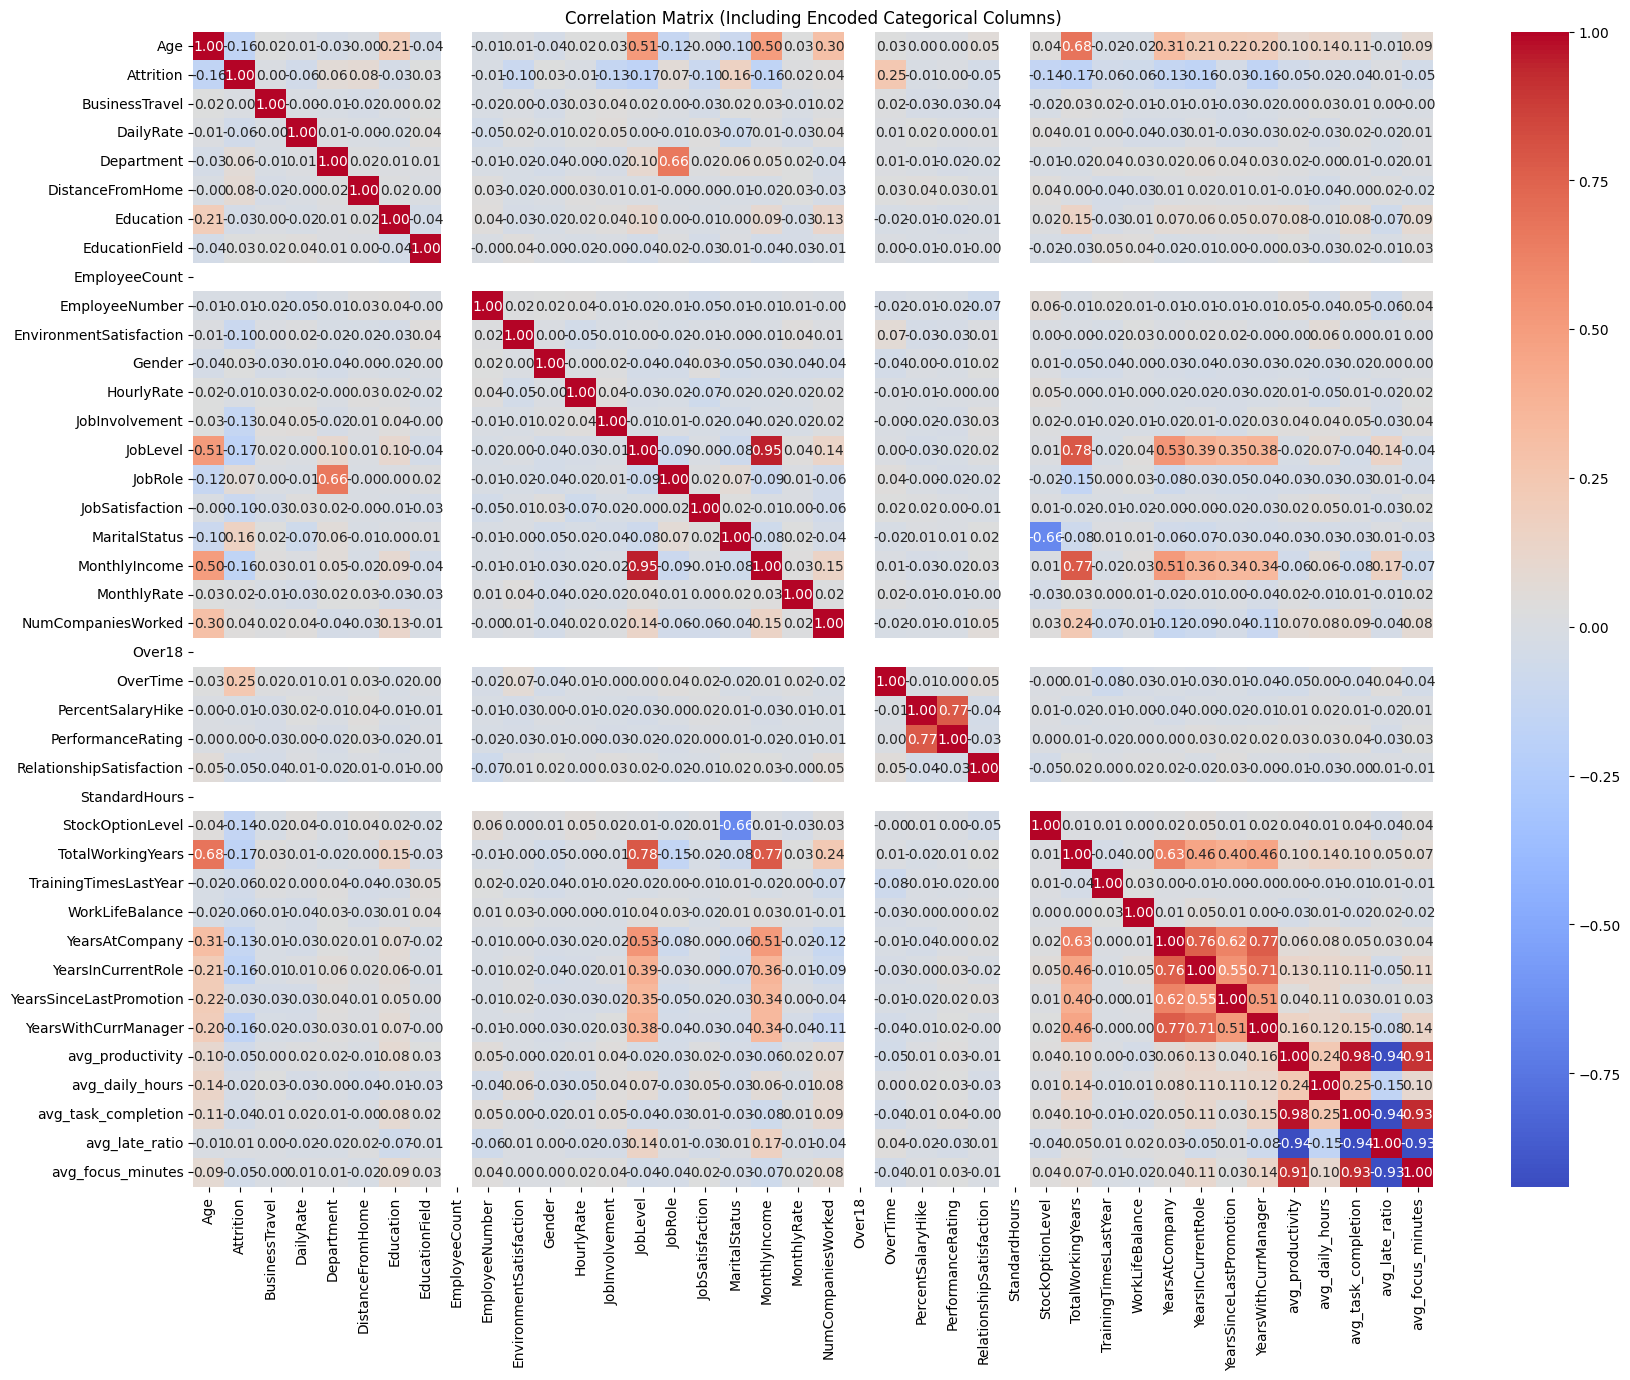

In [ ]:
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['category']).columns:
    df_encoded[col] = df_encoded[col].cat.codes


plt.figure(figsize=(20,15))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix (Including Encoded Categorical Columns)")
plt.show()

The correlation matrix shows how different variables are related to each other. Most variables have weak correlations with Attrition, which means there is no single strong factor that directly explains why employees leave. Overtime shows a small positive relationship with Attrition, suggesting employees who work overtime may be more likely to leave. MonthlyIncome is strongly correlated with JobLevel and TotalWorkingYears, which makes sense because more experienced employees usually earn higher salaries. The productivity variables are highly correlated with each other, meaning they capture similar patterns. Therefore, employee attrition appears to be influenced by multiple factors rather than one dominant variable.

##### Employee Attrition Distribution 

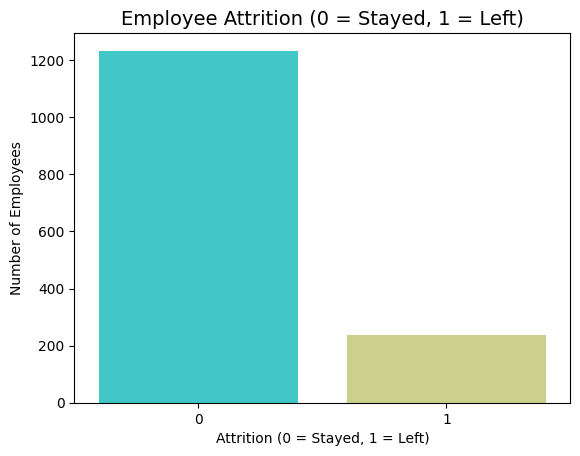

In [43]:
sns.countplot(
    x='Attrition',
    data=df,
    hue='Attrition',
    palette='rainbow',
    legend=False
)

plt.title("Employee Attrition (0 = Stayed, 1 = Left)", fontsize=14)
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Employees")

plt.show()

The chart shows that most employees did not leave the company (Attrition = 0). Only a much smaller number of employees left (Attrition = 1). This indicates that the dataset is imbalanced, with significantly more employees staying than leaving.

##### Average Productivity by Employee Attrition Status

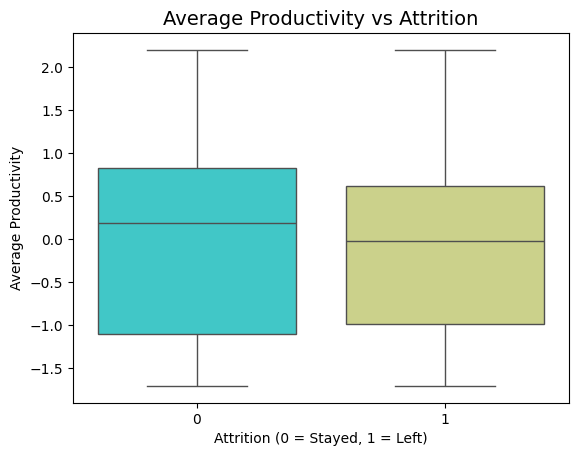

In [47]:
sns.boxplot(
    x='Attrition',
    y='avg_productivity',
    data=df,
    hue='Attrition',
    palette='rainbow',
    legend=False
)

plt.title("Average Productivity vs Attrition", fontsize=14)
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Average Productivity")

plt.show()

The boxplot compares average productivity between employees who stayed (0) and those who left (1). The median productivity levels are similar for both groups, with only small differences. The spread of productivity values also overlaps significantly. This suggests that average productivity alone may not strongly explain employee attrition.

##### Employee Attrition by Overtime Status

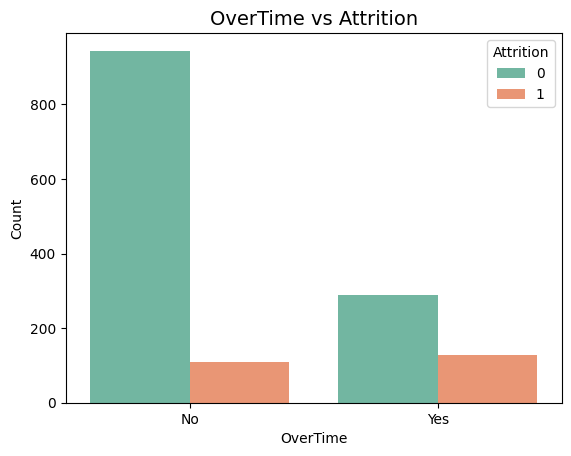

In [48]:
sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df,
    palette='Set2'
)

plt.title("OverTime vs Attrition", fontsize=14)
plt.xlabel("OverTime")
plt.ylabel("Count")

plt.show()

The chart shows that employees who work overtime have a higher proportion of attrition compared to those who do not work overtime. While most employees in both groups stayed, the number of employees who left is noticeably higher among those working overtime. This suggests that overtime may be associated with an increased likelihood of leaving the company.

##### Pairwise Relationships Among Monthly Income, Total Working Years, and Productivity Metrics by Attrition Status

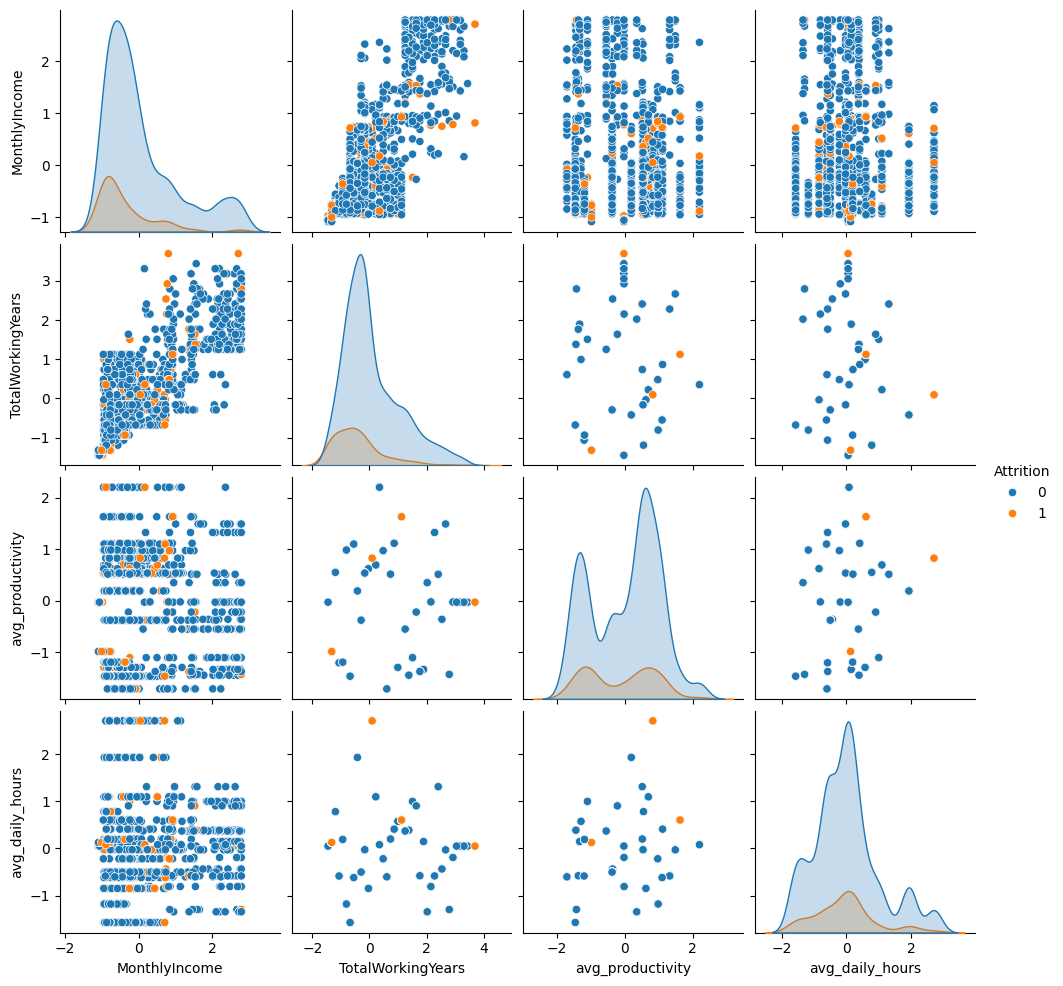

In [36]:
sns.pairplot(df[['MonthlyIncome','TotalWorkingYears','avg_productivity','avg_daily_hours','Attrition']],
             hue='Attrition', diag_kind='kde')
plt.show()

##### Job Satisfaction by Employee Attrition Status

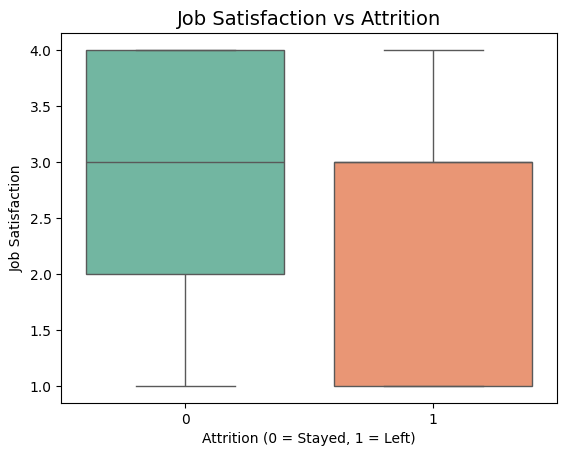

In [56]:
sns.boxplot(
    x='Attrition',
    y='JobSatisfaction',
    data=df,
    hue='Attrition',
    palette='Set2',
    legend=False
)

plt.title("Job Satisfaction vs Attrition", fontsize=14)
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Job Satisfaction")

plt.show()

The boxplot indicates that employees who left the company (Attrition = 1) generally have lower job satisfaction compared to those who stayed (Attrition = 0). The median job satisfaction for employees who stayed is higher, while employees who left tend to cluster around lower satisfaction levels. Thus, that lower job satisfaction may be associated with a higher chance of leaving the company.

##### Monthly Income by Employee Attrition Status

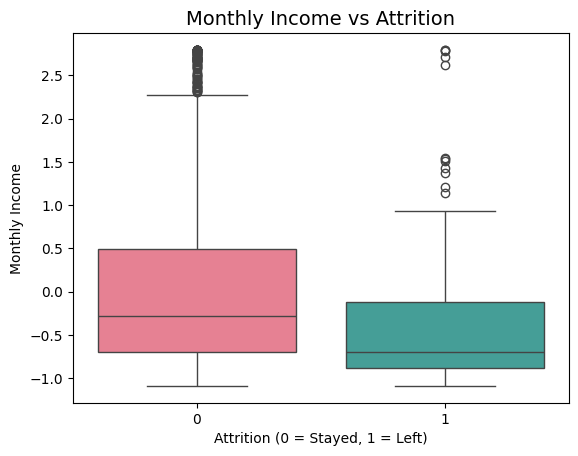

In [58]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df,
    hue='Attrition',
    palette='husl',
    legend=False
)

plt.title("Monthly Income vs Attrition", fontsize=14)
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.show()

The boxplot shows that employees who left the company (Attrition = 1) tend to have lower monthly income compared to those who stayed (Attrition = 0). The median income for employees who stayed is higher, while those who left are generally concentrated in lower income ranges. Lower monthly income may be associated with a higher level of employee attrition.

##### Years at Company by Employee Attrition Status

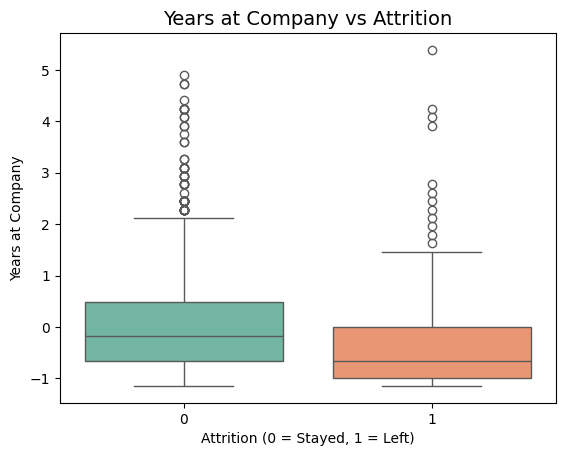

In [63]:
sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df,
    hue='Attrition',
    palette='Set2',
    legend=False
)

plt.title("Years at Company vs Attrition", fontsize=14)
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Years at Company")

plt.show()

The boxplot shows that employees who left the company (Attrition = 1) generally have fewer years at the company compared to those who stayed (Attrition = 0). The median tenure is lower for employees who left, indicating that newer employees are more likely to leave. We can say that shorter tenure may be associated with higher employee attrition.

##### Employee Attrition by Job Level

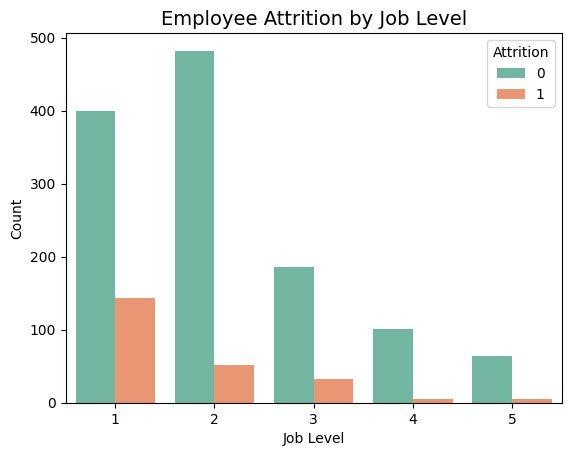

In [64]:
sns.countplot(
    x='JobLevel',
    hue='Attrition',
    data=df,
    palette='Set2'
)

plt.title("Employee Attrition by Job Level", fontsize=14)
plt.xlabel("Job Level")
plt.ylabel("Count")

plt.show()

The chart illustrates that lower job levels (especially JobLevel 1 and 2) have more attrition cases compared to higher job levels. As job level increases, the number of employees who leave decreases. Employees in lower positions appear to leave the company more often, while higher-level employees tend to remain longer. Hence, job level appears to be an important workplace factor related to employee attrition.